/tmp/ipython-input-1-2864875565.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


NameError: name 'window' is not defined

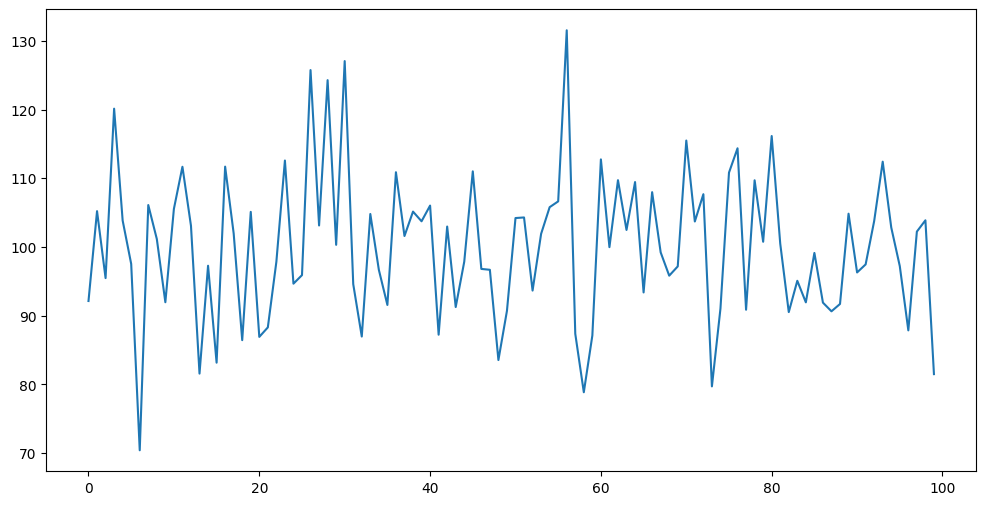

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample project: Stock market analysis
# Load and clean stock data, perform EDA, and compute rolling metrics

# 1. Data Loading
def load_stock_data(file_path):
    df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
    return df

# 2. Data Cleaning
def clean_stock_data(df):
    # Handle missing values
    df = df.fillna(method='ffill')
    # Remove outliers (e.g., price > 3 std deviations)
    df = df[np.abs(df['Close'] - df['Close'].mean()) <= (3 * df['Close'].std())]
    return df

# 3. Analysis: Compute rolling mean and volatility
def analyze_stock(df, window=20):
    df['Rolling_Mean'] = df['Close'].rolling(window=window).mean()
    df['Volatility'] = df['Close'].rolling(window=window).std()
    return df

# 4. Visualization
def plot_stock_analysis(df, ticker):
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Close'], label='Close Price')
    plt.plot(df.index, df['Rolling_Mean'], label=f'{window}-Day Rolling Mean')
    plt.title(f'{ticker} Stock Analysis')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Main execution
if __name__ == "__main__":
    # Sample data (replace with actual stock CSV)
    data = {
        'Date': pd.date_range(start='2023-01-01', periods=100, freq='D'),
        'Close': np.random.normal(100, 10, 100)
    }
    df = pd.DataFrame(data)
    df = clean_stock_data(df)
    df = analyze_stock(df)
    plot_stock_analysis(df, 'SAMPLE')
